# Week 4 - Cartography and Birthquakes!

# Finding Birthquakes

Your birthquake is the largest magnitude earthquake that occured on the day you were born. In this in-class exercise, we are going to search an earthquake catalog and find your birthquake.

To do so, we can going to download data from the US Geological Survey (USGS) Earthquake Hazards program. https://earthquake.usgs.gov

We are going to use an API that lets us send an url to the USGS and get earthquake information for a set of specified parameters. 

## Exercise 1 - Finding my birthquake

Let's do it first for my birthday. We will define my birthday in year-month-day format and the day after my birthday in year-month-day format in order to make a url that gets data starting on 12 am of your birthday and ending 12 am of the next day. We are putting the quote marks (' ') around the dates so that they are **strings** (the Python data type that is a sequence of text).

In [16]:
## e.g., my_birthday = '1990-01-01'
my_birthday = '2004-09-25'

We are going to need to tell the USGS to look for earthquakes that are bracketed between the start of the day on my birthday and the end of the day on my birthday for which we can assign a variable named `day_after_my_birthday`. Python variable names cannot have spaces in them which is why I am using underscores `_`.

In [17]:
## e.g., day_after_my_birthday = '1990-01-02'
day_after_my_birthday = '2004-09-26'

### Defining my birthday earthquake URL

To make a url that we can send to the USGS and get back data, we need to insert these dates into the USGS earthquake API url format (https://earthquake.usgs.gov/fdsnws/event/1/). API stands for 'application programming interface' and an API url path provides a way to access data that are available online. A nice thing about using an API url to access data is that it makes code portable and reproducible as the code can grab the data from the internet without needing a local copy.

We will define the `standard_url` as a string and include that we want to get the data as a `csv` with `format=csv` and that we want the data to be in the order of magitude with `&orderby=magnitude`. We can then add the dates that were set above to be the `&starttime` and `&endtime`.

In [18]:
standard_url = 'https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&orderby=magnitude'

my_birthquake_url = (standard_url + '&starttime=' + 
                       my_birthday + '&endtime=' + 
                       day_after_my_birthday)

Take a look at the url that is created:

In [19]:
my_birthquake_url

'https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&orderby=magnitude&starttime=2004-09-25&endtime=2004-09-26'

In [20]:
print(my_birthquake_url)

https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&orderby=magnitude&starttime=2004-09-25&endtime=2004-09-26


### Getting my's birthday earthquakes

We now have a url that we can use to get data from the USGS. We could cut and paste this url into a web browser. Go ahead and give that a try.

Alternatively, we can use functions from the `pandas` module to get these data. The standard way to use ```pandas``` is to import it with the shorthand ```pd```. We will use the ```pd.read_csv()``` function which will take the data that comes from the USGS url and make it into a `DataFrame`. A `DataFrame` is a data structure with columns of different data that are defined with column names.

In [21]:
# import Pandas 
import pandas as pd

## e.g., my_birthday_earthquakes = pd.read_csv(my_birthquake_url)
my_birthday_earthquakes = pd.read_csv(my_birthquake_url)

These data are sorted by magnitude with the largest magnitude earthquakes at top. Let's look at the first 5 rows of the DataFrame using the ```.head()``` function.

In [22]:
my_birthday_earthquakes.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2004-09-25T16:04:16.970Z,-7.753,107.963,86.6,5.1,mwc,102.0,28.4,NaN,1.10,...,2025-12-19T23:16:30.759Z,"47 km SSW of Singaparna, Indonesia",earthquake,NaN,6.2,NaN,NaN,reviewed,us,hrv
1,2004-09-25T02:14:15.720Z,-0.117,122.971,130.8,5.0,mwc,130.0,50.9,NaN,0.98,...,2025-12-19T23:16:29.543Z,"73 km S of Gorontalo, Indonesia",earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv
2,2004-09-25T08:37:29.030Z,2.425,95.837,23.5,4.8,mb,33.0,92.8,NaN,0.93,...,2014-11-07T01:23:33.413Z,"60 km W of Sinabang, Indonesia",earthquake,NaN,NaN,NaN,17.0,reviewed,us,us
3,2004-09-25T08:43:57.550Z,-6.152,149.133,66.3,4.8,mwc,29.0,72.7,NaN,0.89,...,2016-11-10T00:46:53.335Z,"46 km W of Kandrian, Papua New Guinea",earthquake,NaN,8.0,NaN,NaN,reviewed,us,hrv
4,2004-09-25T21:20:57.510Z,5.150,95.869,70.4,4.8,mb,19.0,152.1,NaN,0.99,...,2014-11-07T01:23:33.551Z,"27 km SSW of Sigli, Indonesia",earthquake,NaN,20.7,NaN,7.0,reviewed,us,us


In [23]:
sorted_my_birthday_earthquakes = my_birthday_earthquakes.sort_values(by='mag', ascending=False)

In [24]:
sorted_my_birthday_earthquakes.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2004-09-25T16:04:16.970Z,-7.753,107.963,86.6,5.1,mwc,102.0,28.4,NaN,1.10,...,2025-12-19T23:16:30.759Z,"47 km SSW of Singaparna, Indonesia",earthquake,NaN,6.2,NaN,NaN,reviewed,us,hrv
1,2004-09-25T02:14:15.720Z,-0.117,122.971,130.8,5.0,mwc,130.0,50.9,NaN,0.98,...,2025-12-19T23:16:29.543Z,"73 km S of Gorontalo, Indonesia",earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv
2,2004-09-25T08:37:29.030Z,2.425,95.837,23.5,4.8,mb,33.0,92.8,NaN,0.93,...,2014-11-07T01:23:33.413Z,"60 km W of Sinabang, Indonesia",earthquake,NaN,NaN,NaN,17.0,reviewed,us,us
3,2004-09-25T08:43:57.550Z,-6.152,149.133,66.3,4.8,mwc,29.0,72.7,NaN,0.89,...,2016-11-10T00:46:53.335Z,"46 km W of Kandrian, Papua New Guinea",earthquake,NaN,8.0,NaN,NaN,reviewed,us,hrv
4,2004-09-25T21:20:57.510Z,5.150,95.869,70.4,4.8,mb,19.0,152.1,NaN,0.99,...,2014-11-07T01:23:33.551Z,"27 km SSW of Sigli, Indonesia",earthquake,NaN,20.7,NaN,7.0,reviewed,us,us


We can just look at values in one row by applying the ```.loc``` function to the DataFrame and calling the index 0. Python is zero-indexed (just like human ages!) so the first row is row zero. Please apply .loc to the first row to see all the details about my birthquake.

In [25]:
my_birthday_earthquakes.loc[0]

time                         2004-09-25T16:04:16.970Z
latitude                                       -7.753
longitude                                     107.963
depth                                            86.6
mag                                               5.1
magType                                           mwc
nst                                             102.0
gap                                              28.4
dmin                                              NaN
rms                                               1.1
net                                                us
id                                         usp000d51g
updated                      2025-12-19T23:16:30.759Z
place              47 km SSW of Singaparna, Indonesia
type                                       earthquake
horizontalError                                   NaN
depthError                                        6.2
magError                                          NaN
magNst                      

It can be useful to return a single value which can be done by calling both the the row and the column using the ```.loc``` function. Please apply .loc to the first row and the column 'mag' to see the magnitude of my birthquake.

In [26]:
my_birthday_earthquakes.loc[0,'mag']

np.float64(5.1)

What is the magnitude of your birthquake? Where did it occur?

Rerun the code above, changing the dates etc. to match your birthquake.

Use print statements to show your answers.

(15 points)

In [27]:
print(f"The largest earthquake on {my_birthday} had a magnitude of {my_birthday_earthquakes.loc[:,'mag'].max()}.")

The largest earthquake on 2004-09-25 had a magnitude of 5.1.


In [28]:
my_birthday_earthquakes.loc[my_birthday_earthquakes['mag'] == my_birthday_earthquakes['mag'].max()]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2004-09-25T16:04:16.970Z,-7.753,107.963,86.6,5.1,mwc,102.0,28.4,NaN,1.1,...,2025-12-19T23:16:30.759Z,"47 km SSW of Singaparna, Indonesia",earthquake,NaN,6.2,NaN,NaN,reviewed,us,hrv


In [29]:
print(f"The earthquake occurred at a longitude of {my_birthday_earthquakes.loc[my_birthday_earthquakes['mag'] == my_birthday_earthquakes['mag'].max()]['longitude'].iloc[0]} $^o$E and a latitude of {my_birthday_earthquakes.loc[my_birthday_earthquakes['mag'] == my_birthday_earthquakes['mag'].max()]['latitude'].iloc[0]} $^o$N.")

The earthquake occurred at a longitude of 107.963 $^o$E and a latitude of -7.753 $^o$N.


When working with Python for this course, you are going to get errors. I get errors almost everyday. Programming languages are not flexible and want things to be just so. 

Error messages can look quite intimidating, but they often are informative (particularly if you look at the bottom). For example, the code cell below should result in an error. Go ahead and execute it and let's have a look at the result.

In [30]:
my_birthday_earthquakes.loc[0]['birthday_cake']

KeyError: 'birthday_cake'

# Map projections and making your birthquake map

The purpose of this introduction is to give you a bit of a background on map projections and other geospatial concepts. This will help you to:
 
 * choose map projections that are appropriate for plotting data
 * understand the terms used in the ```cartopy``` functions which is a function library we will use for plotting geospatial data

# The world *is not* flat / 2D (sorry flat-Earthers)

<img src="figures/azim-eq.png" style="max-height: 55vh; margin-left: auto; margin-right: auto;">

"Azimuthal equidistant projections of the sphere ... have been co-opted as images of the flat Earth model, depicting Antarctica as an ice wall surrounding a disk-shaped Earth." ([Wikipedia: Flat Earth](https://en.wikipedia.org/wiki/Flat_Earth#Flat_Earth_Society))

## Most of our media for visualization *are* flat

Our two most common media are flat:

 * Paper
 * Screen

### But there are *a few* that aren't...

For example:

 * 3D rendering engine (the engine is then typically responsible for projecting the data to 2D for presentation to screen)
 * A Spherical Projector...


## [Map] Projections: Taking us from spherical to flat

A map projection (or more commonly refered to as just "projection") is:

> a systematic transformation of the latitudes and longitudes of locations from the surface of a sphere or an ellipsoid into locations on a plane. [[Wikipedia: Map projection](https://en.wikipedia.org/wiki/Map_projection)].

## The major problem with map projections

<img src="figures/orange_peel.jpg" style="margin-left: auto; margin-right: auto;">

 * The surface of a sphere is topologically different to a 2D surface, therefore we *have* to cut the sphere *somewhere*
 * A sphere's surface cannot be represented on a plane without distortion.
 
**Watch the video embedded below** (*click the notebook play button to embed it in the notebook or watch it at this link: https://youtu.be/kIID5FDi2JQ*). This video gives an introduction (with nice accompanying visualizations) of this issue and different projections along with the positives and negatives of different commonly used ones.

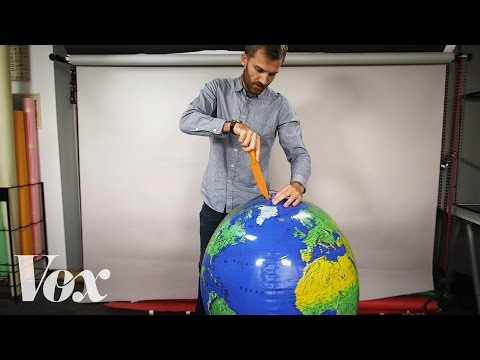

In [31]:
from IPython.lib.display import YouTubeVideo
YouTubeVideo('kIID5FDi2JQ')

### Different projections

We are going to use the function library `cartopy` to make maps. `cartopy`  supports a number of different map projections which enable the 3 dimensional surface of Earth to be shown in 2 dimensions on our computer screens. Having watched the above video will give you some context to appreciate these jokes:

<img src="figures/map_projections.png" style="margin-left: auto; margin-right: auto;">

You can check out the list of projections supported by `cartopy` here: https://scitools.org.uk/cartopy/docs/v0.15/crs/projections.html

### Common distortions of map projections

Properties of maps that are often not preserved in projections:

* Area
* Shape
* Direction
* Distance
* Scale

> all ~~models~~ map projections are wrong, but some are useful - Phileas Elson (SciPy 2018)

## Classifying projections

Two common approaches:

 1. By [2D] surface classification
 2. By preserving a given property (metric)

### Projections by surface classification

<!-- ![](./figures/projections.png) -->
<img src="figures/projections.png">

*Downside: Not all projections can be classified in this way -> Leads to big "pseudo" and "other" groups.*

## Surface classification: Cylindrical

<img src="figures/cylindrical.png">
<p style="font-size: xx-small; float: right;">
Source: http://ayresriverblog.com/2011/05/19/the-world-is-flat/
</p>


* Meridians and paralells are straight and perpendicular.


## Surface classification: Azimuthal

<img src="figures/azimuthal.png">
<p style="font-size: xx-small; float: right;">
Source: http://ayresriverblog.com/2011/05/19/the-world-is-flat/
</p>


* Parallels are complete circles
* Great circles from central point are straight lines.

## Surface classification: Conic
<img src="figures/conic.png">
<p style="font-size: xx-small; float: right;">
Source: http://ayresriverblog.com/2011/05/19/the-world-is-flat/
</p>

* Meridians are straight equally-spaced lines
* Parallels are circular arcs.

### Projections by preserving metric

Downside: Some projections can live in multiple groups.

## Preserving metric: Conformal

Also known as Orthomorphic.

These projections preserve angles locally. Implying that circles anywhere on the Earth's surface map to circles of *varying size* in the projected space.

Examples of conformal projections:

 * Mercator
 * Transverse Mercator
 * Stereographic
 * Lambert conformal conic

## Preserving metric: Conformal

### Use in large scale maps (zoomed in)

Often used to preserve shape to represent their physical counterpart.
Seamless online maps like OSM/Google/Bing typically use a Mercator projection although Google Maps has begun using an 3D-rendered globe projection when the user zooms out:

> The first launch of [Google] Maps actually did not use Mercator, and streets in high latitude places like Stockholm did not meet at right angles on the map the way they do in reality. [[ref](https://productforums.google.com/d/msg/maps/A2ygEJ5eG-o/KbZr_B0h2hkJ)]

The major drawback: it is difficult to compare lengths or areas

## Preserving metric: Conformal

### Use in small scale maps (zoomed out)

Maps reflecting directions, such as an [aero]nautical chart, or whose gradients are important,
such as a weather maps, are often projected by conformal projections.

Historically, many world maps are drawn by conformal projections, but the fact that the scale of the map
varies by location makes it difficult to compare lengths or areas.
Some have gone as far as calling the Mercator projection imperialistic and racist.


## Preserving metric: Equidistant

No map projection can be universally equidistant.

Some projections preserve distance from some standard point or line.

Examples of projections that preserve distances along meridians (but not parallels):

 * Equirectangular / Plate Carree
 * Azimuthal equidistant


## Preserving metric: Equal-area


Equal-area maps preserve area measure, generally distorting shapes in order to do so.

Examples of equal area projections:
 * Albers conic
 * Eckert IV
 * Goode's homolosine
 * Lambert azimuthal equal-area
 * Lambert cylindrical equal-area
 * Mollweide
 * Sinusoidal

## Preserving metric: Compromise

Rather than perfectly preserving any metric properties, compromise
projections aim strike a balance between distortions.
These compromises are often at the cost of polar distortions.

Examples:
    
 * Miller
 * Robinson
 * Winkel Tripel

## Tissot's indicatrix

A mathematical contrivance in order to characterize local distortions of a map projection. Multiple circles (on the sphere/ellipse) of constant area are drawn on the map. By analysing the distortions, we can identify (or more often rule-out) particular preserving metrics. You can see how dramatic the distortion is in an equirectangular projection. 


<img src="figures/tissot.platecarree.1000km.png" style="margin-left: auto; margin-right: auto;">


## Exercise 2 - Let's make your first map!

We are going to use ```cartopy``` in conjunction with ```matplotlib``` to make maps. ```cartopy``` can transform points, lines and images into different map projections. ```matplotlib``` provides tools to visualize these projections. We will import them using the standard conventions. **You must press play (or more efficiently shift+enter) on the cell that imports these function libraries for the rest of the code to work.**

In [32]:
# If you are running this notebook locally (not on the Berkeley Hub) then you will likely need to uncomment and run the line below
# !pip install cartopy

In [33]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

The syntax of using these functions takes some getting used to. Here we will make a figure, create an axis object with a defined projection, and then plot coastlines and a stock image that shows elevation.

/usr/local/Caskroom/miniforge/base/envs/EPS88_Gleeson/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Caskroom/miniforge/base/envs/EPS88_Gleeson/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


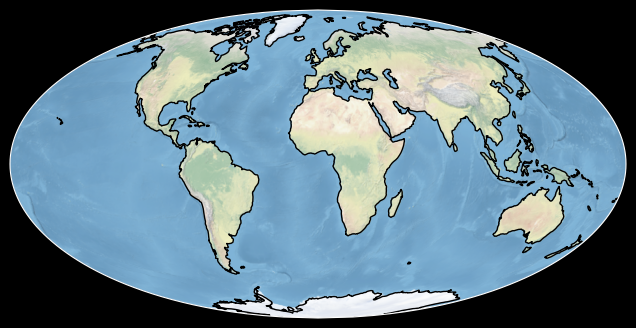

In [34]:
plt.figure(figsize=(8, 4))
ax = plt.axes(projection=ccrs.Mollweide())
ax.coastlines()
ax.stock_img()
plt.show()

Let's plot the location of Berkeley on a map. First we want to assign the latitude and longitude of Berkeley to variables:

In [35]:
Berkeley_latitude = 37.8715
Berkeley_longitude = -122.2730

Now we can use the ```plt.scatter()``` function to plot the location of Berkeley. ```plt.scatter()``` is one of the many plotting functions available using the ```matplotlib``` library that we imported above using ```import matplotlib.pyplot as plt```.

We give the ```plt.scatter()``` function ```Berkeley_longitude``` as the x-value, ```Berkeley_latitude``` as the y-value while also telling it to transform it into map coordinates (```transform=ccrs.PlateCarree()```) and to make the point red (```color='red'```). 

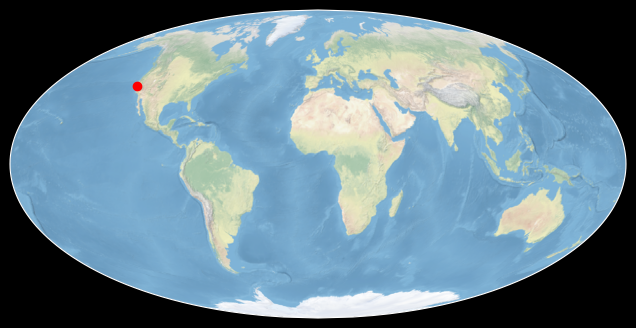

In [36]:
plt.figure(figsize=(8, 4))
ax = plt.axes(projection=ccrs.Mollweide())
ax.stock_img()
plt.scatter(Berkeley_longitude, Berkeley_latitude, 
            transform=ccrs.PlateCarree(), color='red')
plt.show()

Revisit the above notebook when you found your birthquake and enter the latitude of longitude in the cell below assigning them to ```birthquake_latitude``` and ```birthquake_longitude```.

(5 points)

In [37]:
birthquake_longitude = 107.963
birthquake_latitude = -7.753

Once ```birthquake_latitude``` and ```birthquake_longitude``` are defined, we can plot them instead of the position of Berkeley. Replace the ellipsis (`...`) with ```birthquake_latitude``` and ```birthquake_longitude``` in the cell below:

(5 points)

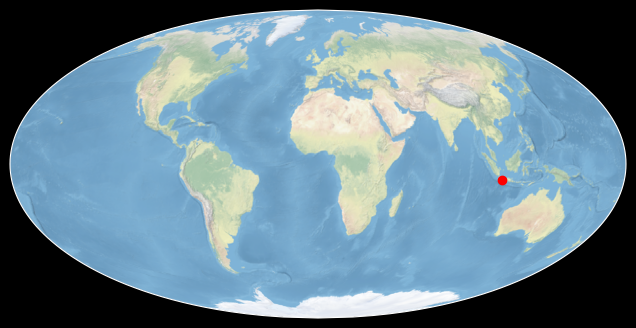

In [38]:
plt.figure(figsize=(8, 4))
ax = plt.axes(projection=ccrs.Mollweide())
ax.stock_img()
plt.scatter(birthquake_longitude, birthquake_latitude,
            transform=ccrs.PlateCarree(), color='red')
plt.show()

Now let's plot both the location of Berkeley and the location of your birthquake. Rather than a single values for x (i.e. a single value of longitude) and a single value for y (i.e. a single value of latitude), we want there to be a list of x values and a list of y values. A list can be defined with square brackets with values separated by commas (e.g. ```[value1, value2]```).

(5 points)

We can save the figure using ```plt.savefig()``` putting the name of the file with the extension within the ```()```. In this case, let's call it ```'map_w_Berkeley_and_birthquake.png'```. Let's also go ahead and add a title to the plot using ```plt.title()```.

(2 points)

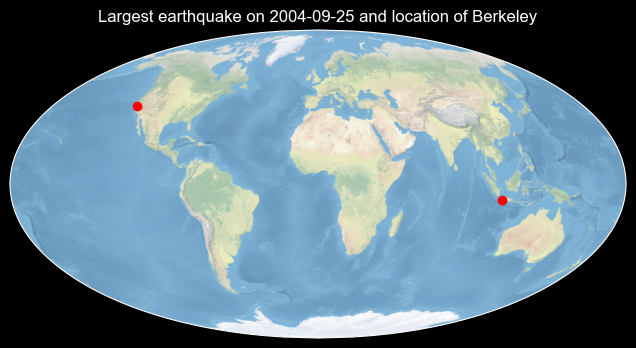

In [39]:
plt.figure(figsize=(8, 4))
ax = plt.axes(projection=ccrs.Mollweide())
ax.stock_img()
plt.scatter([Berkeley_longitude, birthquake_longitude],
            [Berkeley_latitude, birthquake_latitude],
            transform=ccrs.PlateCarree(), color='red')
plt.title(f"Largest earthquake on {my_birthday} and location of Berkeley")
plt.savefig('figures/map_w_Berkeley_and_birthquake.png')

## Exercise 3 - Make a map of 5 largest birthdate earthquakes.

Use the code cells below to make another map where you plot the locations of the 5 largest magnitude earthquakes that occured on the day you were born. Choose any projection you want (https://scitools.org.uk/cartopy/docs/v0.15/crs/projections.html). You can see that the examples above use Robinson and Mollweide projections.

Add a title to the map that has your name in it.

(15 points)

In [40]:
my_birthday_earthquakes.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2004-09-25T16:04:16.970Z,-7.753,107.963,86.6,5.1,mwc,102.0,28.4,NaN,1.10,...,2025-12-19T23:16:30.759Z,"47 km SSW of Singaparna, Indonesia",earthquake,NaN,6.2,NaN,NaN,reviewed,us,hrv
1,2004-09-25T02:14:15.720Z,-0.117,122.971,130.8,5.0,mwc,130.0,50.9,NaN,0.98,...,2025-12-19T23:16:29.543Z,"73 km S of Gorontalo, Indonesia",earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv
2,2004-09-25T08:37:29.030Z,2.425,95.837,23.5,4.8,mb,33.0,92.8,NaN,0.93,...,2014-11-07T01:23:33.413Z,"60 km W of Sinabang, Indonesia",earthquake,NaN,NaN,NaN,17.0,reviewed,us,us
3,2004-09-25T08:43:57.550Z,-6.152,149.133,66.3,4.8,mwc,29.0,72.7,NaN,0.89,...,2016-11-10T00:46:53.335Z,"46 km W of Kandrian, Papua New Guinea",earthquake,NaN,8.0,NaN,NaN,reviewed,us,hrv
4,2004-09-25T21:20:57.510Z,5.150,95.869,70.4,4.8,mb,19.0,152.1,NaN,0.99,...,2014-11-07T01:23:33.551Z,"27 km SSW of Sigli, Indonesia",earthquake,NaN,20.7,NaN,7.0,reviewed,us,us


In [41]:
my_birthday_earthquakes.loc[0:4,'latitude']

0   -7.753
1   -0.117
2    2.425
3   -6.152
4    5.150
Name: latitude, dtype: float64

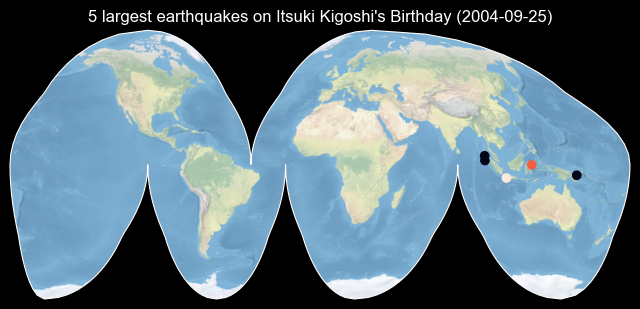

In [42]:
plt.figure(figsize=(8, 4))
ax = plt.axes(projection=ccrs.InterruptedGoodeHomolosine())
ax.stock_img()
plt.scatter(sorted_my_birthday_earthquakes.loc[0:4,'longitude'],
            sorted_my_birthday_earthquakes.loc[0:4,'latitude'],
            transform=ccrs.PlateCarree(),
            c=sorted_my_birthday_earthquakes.loc[0:4,'mag'])
plt.title(f"5 largest earthquakes on Itsuki Kigoshi's Birthday ({my_birthday})")
plt.savefig('figures/map_5_birthquake.png')

## Exercise 4 - Make a map showing all earthquakes that occurred in the month after you were born.

This will require you to understand and reuse several of the code sections that we ran above. First you need to specify new dates (from the day you were born to a date one month later) and download a new dataset. You can then plot these data on a map using any projection you like. As an additional component, try coloring the earthquakes by their magnitude (in the plt.scatter() line use c = df['mag'] where df is the name of your new DataFrame). 

Add a title to the map that has your name in it.

(20 points)

In [43]:
one_month_later = '2004-10-25'

In [44]:
my_monthquake_url = (standard_url + '&starttime=' +
                       my_birthday + '&endtime=' +
                       one_month_later)

In [45]:
my_monthquake_earthquakes = pd.read_csv(my_monthquake_url)

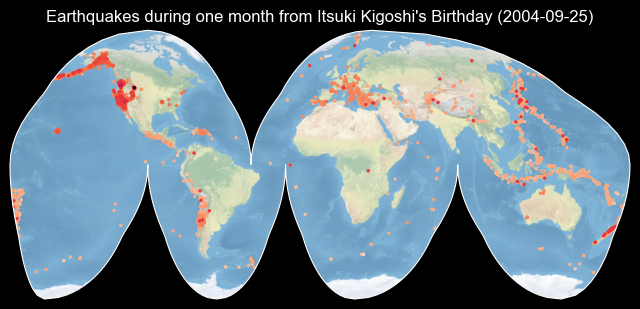

In [46]:
plt.figure(figsize=(8, 4))
ax = plt.axes(projection=ccrs.InterruptedGoodeHomolosine())
ax.stock_img()
plt.scatter(my_monthquake_earthquakes.loc[:,'longitude'],
            my_monthquake_earthquakes.loc[:,'latitude'],
            transform=ccrs.PlateCarree(),
            c=my_monthquake_earthquakes.loc[:,'mag'],
            s=2)
plt.title(f"Earthquakes during one month from Itsuki Kigoshi's Birthday ({my_birthday})")
plt.savefig('figures/map_of_monthquake.png')

**We obviously live in an area with a significant earthquake hazard. Go take a selfie with one of the features on the 'Hayward Fault Walking Tour' and upload it along with this submission.**

(10 points)

<img src="figures/IMG_0737.png">

# Acknowledgments

This introductory text is modified by Prof. Nicholas Swanson-Hysell from a tutorial on working with geospatial data using the library ```cartopy``` that was presented at the 2018 Scipy conference by Phileas Elson (lots of great things to learn in this tutorial if you want to dig into it at some point):

https://youtu.be/AmidIx6Jmn8

https://github.com/SciTools/cartopy-tutorial

The materials in the linked to tutorials were licensed with an open license as long as they original source is acknowledged.